In [26]:
from Bio import SeqIO
import pandas as pd
import csv
from matplotlib import pyplot as plt
import seaborn as sns

def avg(l):
    t = 0
    for i in l:
        t += i
    return t/len(l)

with open('fasta/c_start_seq_ol.fasta', 'r') as seq_ol:
    aligned_seqs = list(SeqIO.parse(seq_ol, 'fasta'))

aligned_seqs_dict = {}
for seq in aligned_seqs:
    aligned_seqs_dict[seq.id] = str(seq.seq)

binned_data_seqs = {'id':[], 'category':[], 'aligned_seq':[], 'size':[]}

with open('csv/condensation_starter_train.csv') as binned_data:
    reader = csv.reader(binned_data, delimiter=',')
    for row in reader:
        if row[1] in ['AR', 'SCFA', 'MCFA', 'LCFA']:
            binned_data_seqs['id'].append(row[4])
            binned_data_seqs['category'].append(row[1])
            binned_data_seqs['size'].append(row[2])
            binned_data_seqs['aligned_seq'].append(aligned_seqs_dict[row[4]])
            #print(aligned_seqs_dict[row[2]][358],aligned_seqs_dict[row[2]][359])

df = pd.DataFrame(binned_data_seqs)

aa_properties_ref = {}
properties_list = []
with open('properties/15_aa_properties.csv', 'r') as aa_properties:
    reader = csv.DictReader(aa_properties, delimiter=',')
    for row in reader:
        aa_properties_ref[row["AA_ABREV"]] = {}
        for aa_property in row:
            if aa_property != "AA_ABREV":
                aa_properties_ref[row["AA_ABREV"]][aa_property] = row[aa_property]
                if not aa_property in properties_list:
                    properties_list.append(aa_property)

aa_properties = {
    'WOLS870101': True,
    'WOLS870102': 1,
    'WOLS870103': True,
    'FAUJ880109': False,
    'GRAR740102': 1,
    'RADA880108': 1,
    'ZIMJ680103': False,
    'TSAJ990101': False,
    'CHOP780201': 0,
    'CHOP780202': 0,
    'CHOP780203': 0,
    'ZIMJ680104': False,
    'NEU1': False,
    'NEU2': False,
    'NEU3': False
}


#aa_positions = [750,773,161,555,548,123,134,710,150,769,821,227]
aa_positions = [121,122,123,355,356,357,362,363,364,365,357,641,643,730,732,766,768,769,770,783,791] #6Å active site
aa_positions = [121, 123, 355, 730, 732, 734, 769, 360,361,362,363,364,365,766,767, 622,537]
aa_positions = [121,122,123,367,369,373,732,766,768,789,791,825,827,538,539,545,546,547,548, 622,537]
aa_positions = [121,122,123,333,353,355,357,364,366,367,371,372,373,730,732,764,766,768,769,770, 622, 537]
#aa_positions = [750,773,161,555,548,123,134,710,150,769,821,227, 121, 355, 730, 732, 734, 769, 360,361,362,363,364,365,766,767]

c = 0
ml_df = df.copy()
for aa_property in aa_properties:
    #if aa_properties[aa_property]:
    if True:
        # print(aa_property)
        for pos in aa_positions:
            c += 1
            ml_df[aa_property + '_' + str(pos)] = df['aligned_seq'].apply(lambda x:float(aa_properties_ref[x[pos]][aa_property]))
            ml_df = ml_df.copy()

def average_size_L(seq):
    avg_size_positions = [121,122,123,332,334,354,355,356,357,363,364,366,367,371,372,373,730,732,764,765,766,768,769,770]
    avg_size_positions = [121,122,123,333,353,355,357,364,366,367,371,372,373,730,732,764,766,768,769,770]

    size_sum = 0
    aa_num = 0
    for pos in avg_size_positions:
        if seq[pos] != '-':
            size_sum += float(aa_properties_ref[seq[pos]]['WOLS870102'])
            aa_num += 1
    return size_sum/aa_num

def average_size_S(seq):
    avg_size_positions = [121,122,364,367,730,732,766,768,769,770,783]
    size_sum = 0
    aa_num = 0
    for pos in avg_size_positions:
        if seq[pos] != '-':
            size_sum += float(aa_properties_ref[seq[pos]]['WOLS870102'])
            aa_num += 1
    return size_sum/aa_num
ml_df['avg_size_tunnel_L'] = df['aligned_seq'].apply(average_size_L)
ml_df['avg_size_tunnel_S'] = df['aligned_seq'].apply(average_size_S)

ml_df = ml_df[ml_df['category'] != 'AR']
#ml_df = ml_df[ml_df['category'] != 'MCFA']

print(ml_df.columns)


Index(['id', 'category', 'aligned_seq', 'size', 'WOLS870101_121',
       'WOLS870101_122', 'WOLS870101_123', 'WOLS870101_333', 'WOLS870101_353',
       'WOLS870101_355',
       ...
       'NEU3_732', 'NEU3_764', 'NEU3_766', 'NEU3_768', 'NEU3_769', 'NEU3_770',
       'NEU3_622', 'NEU3_537', 'avg_size_tunnel_L', 'avg_size_tunnel_S'],
      dtype='object', length=336)


/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_53927/23705328.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=column, hue="category", fill=True, alpha=0.5)


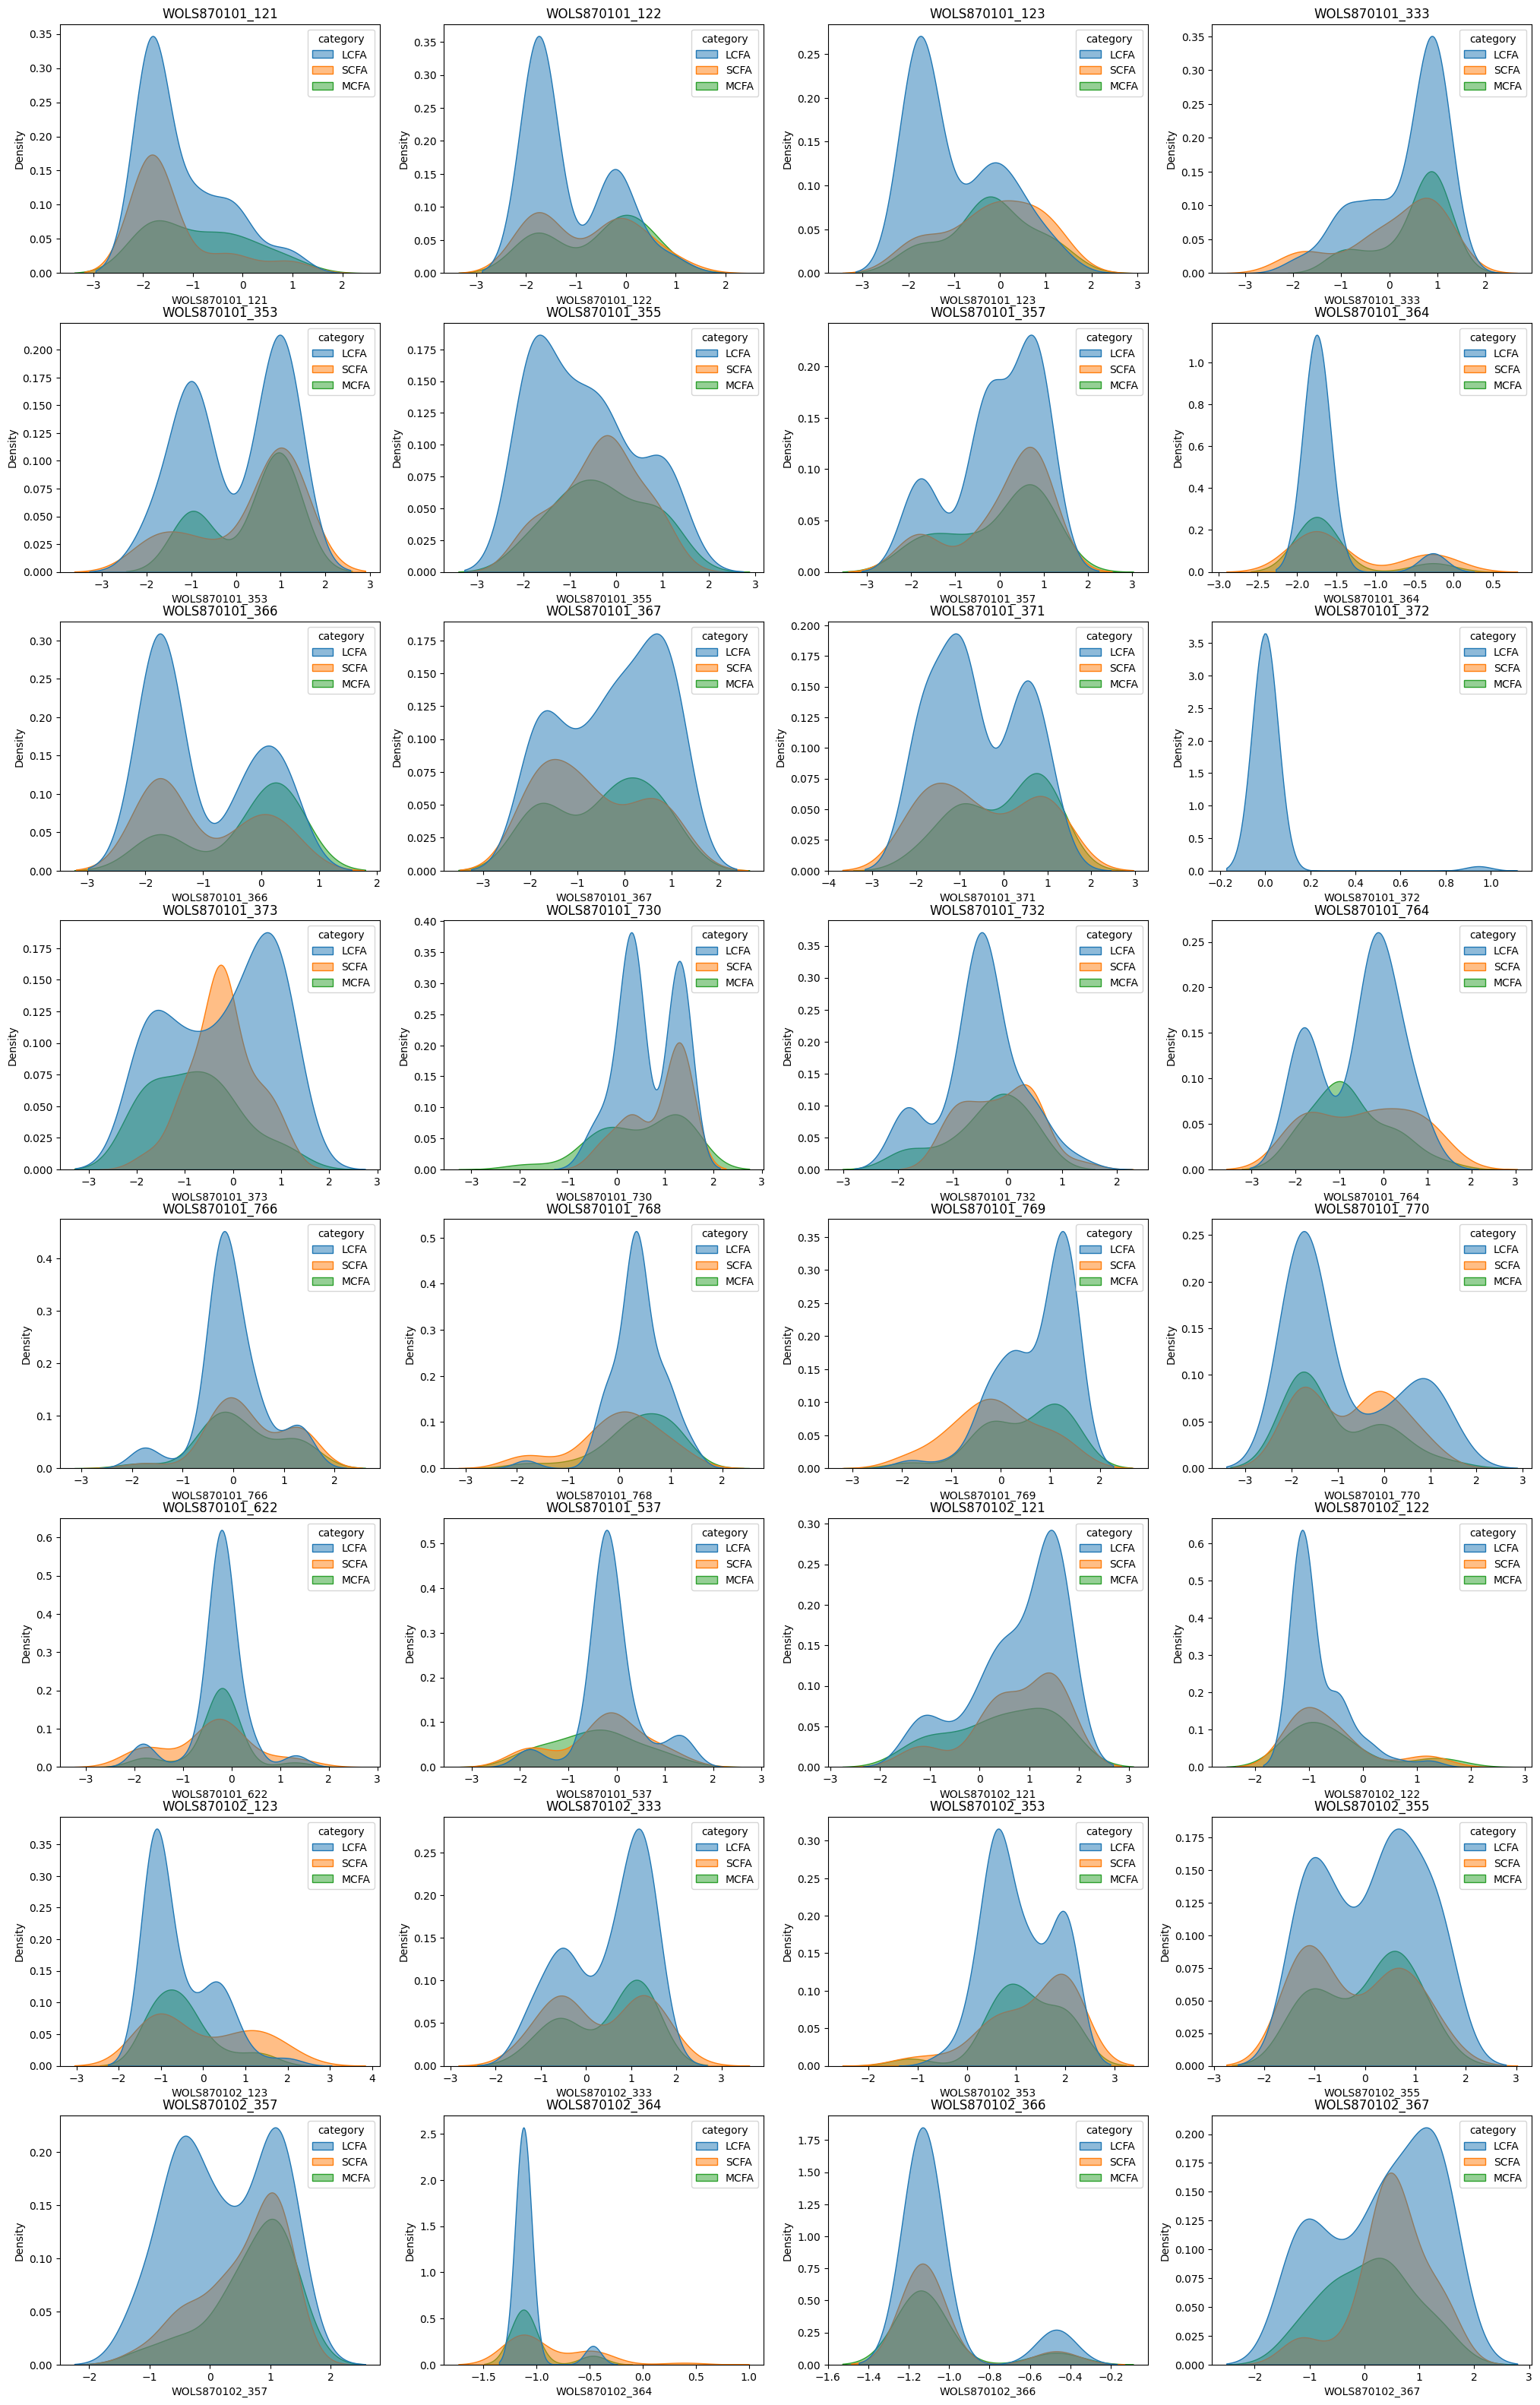

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

df = ml_df.drop(['size', 'aligned_seq', 'id'], axis=1)


numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Set up a reasonably sized figure
plt.figure(figsize=(25, 40))

# Plot KDE for each numeric feature, colored by category
for i, column in enumerate(numeric_columns[:32]):  # Limit to first 10 features for example
    plt.subplot(8, 4, i+1)  # Adjust grid size based on how many features you want to display
    sns.kdeplot(data=df, x=column, hue="category", fill=True, alpha=0.5)
    plt.title(column)
    # plt.tight_layout()


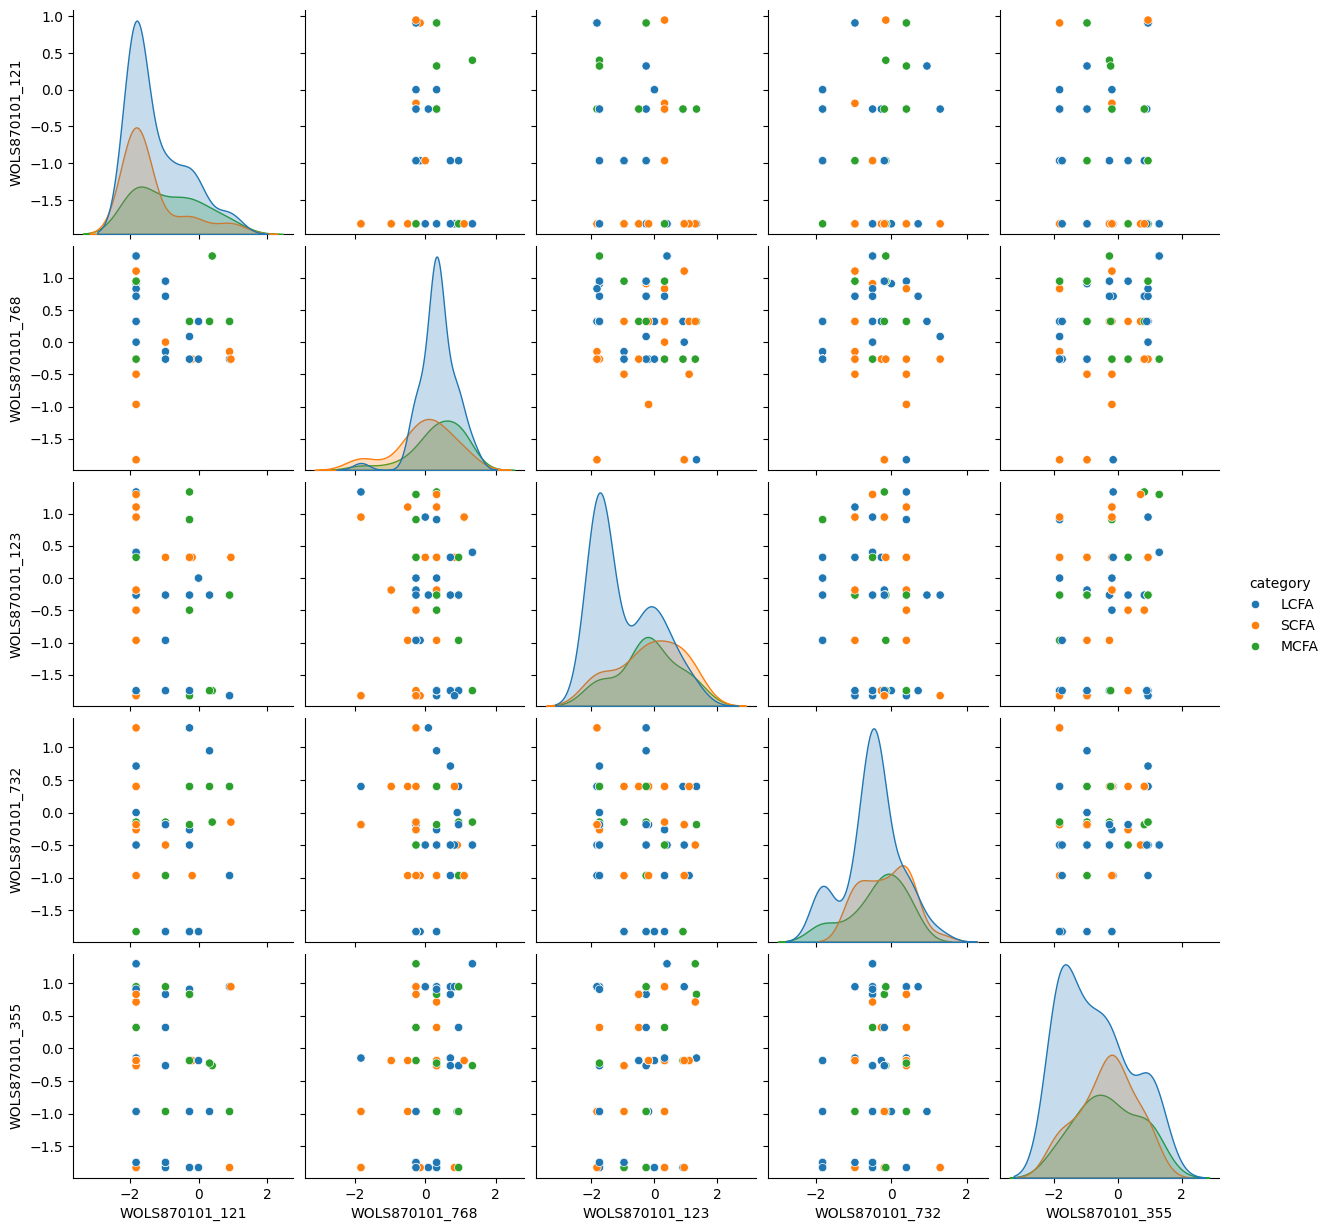

In [32]:
sns.pairplot(ml_df[["WOLS870101_121", "WOLS870101_768", "WOLS870101_123", "WOLS870101_732","WOLS870101_355", "category"]], hue="category")

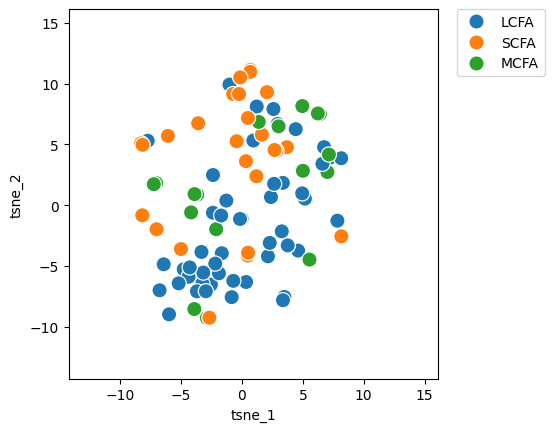

In [33]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

X = ml_df.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)
y = ml_df['category']
n_components = 2
tsne = TSNE(n_components, method='exact')
tsne_result = tsne.fit_transform(X)
tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1], 'label': y})
fig, ax = plt.subplots(1)
sns.scatterplot(x='tsne_1', y='tsne_2', hue='label', data=tsne_result_df, ax=ax,s=120)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

# load test set

In [28]:
from Bio import SeqIO
import pandas as pd
import csv

def avg(l):
    t = 0
    for i in l:
        t += i
    return t/len(l)

with open('fasta/c_start_seq_ol.fasta', 'r') as seq_ol:
    aligned_seqs = list(SeqIO.parse(seq_ol, 'fasta'))

aligned_seqs_dict = {}
for seq in aligned_seqs:
    aligned_seqs_dict[seq.id] = str(seq.seq)

binned_data_seqs = {'id':[], 'category':[], 'aligned_seq':[], 'size':[]}

with open('csv/condensation_starter_test.csv') as binned_data:
    reader = csv.reader(binned_data, delimiter=',')
    for row in reader:
        if row[1] in ['AR', 'SCFA', 'MCFA', 'LCFA']:
            binned_data_seqs['id'].append(row[4])
            binned_data_seqs['category'].append(row[1])
            binned_data_seqs['size'].append(row[2])
            binned_data_seqs['aligned_seq'].append(aligned_seqs_dict[row[4]])
            #print(aligned_seqs_dict[row[2]][358],aligned_seqs_dict[row[2]][359])

df = pd.DataFrame(binned_data_seqs)

aa_properties_ref = {}
properties_list = []
with open('properties/15_aa_properties.csv', 'r') as aa_properties:
    reader = csv.DictReader(aa_properties, delimiter=',')
    for row in reader:
        aa_properties_ref[row["AA_ABREV"]] = {}
        for aa_property in row:
            if aa_property != "AA_ABREV":
                aa_properties_ref[row["AA_ABREV"]][aa_property] = row[aa_property]
                if not aa_property in properties_list:
                    properties_list.append(aa_property)

aa_properties = {
    'WOLS870101': True,
    'WOLS870102': 1,
    'WOLS870103': True,
    'FAUJ880109': False,
    'GRAR740102': 1,
    'RADA880108': 1,
    'ZIMJ680103': False,
    'TSAJ990101': False,
    'CHOP780201': 0,
    'CHOP780202': 0,
    'CHOP780203': 0,
    'ZIMJ680104': False,
    'NEU1': False,
    'NEU2': False,
    'NEU3': False
}


#aa_positions = [750,773,161,555,548,123,134,710,150,769,821,227]
aa_positions = [121,122,123,355,356,357,362,363,364,365,357,641,643,730,732,766,768,769,770,783,791] #6Å active site
aa_positions = [121, 123, 355, 730, 732, 734, 769, 360,361,362,363,364,365,766,767, 622,537]
aa_positions = [121,122,123,367,369,373,732,766,768,789,791,825,827,538,539,545,546,547,548, 622,537]
aa_positions = [121,122,123,333,353,355,357,364,366,367,371,372,373,730,732,764,766,768,769,770, 622, 537]
#aa_positions = [750,773,161,555,548,123,134,710,150,769,821,227, 121, 355, 730, 732, 734, 769, 360,361,362,363,364,365,766,767]

ml_df_test = df.copy()
for aa_property in aa_properties:
    #if aa_properties[aa_property]:
    if True:
        # print(aa_property)
        for pos in aa_positions:
            ml_df_test[aa_property + '_' + str(pos)] = df['aligned_seq'].apply(lambda x:aa_properties_ref[x[pos]][aa_property])
            ml_df_test = ml_df_test.copy()

def average_size_L(seq):
    avg_size_positions = [121,122,123,332,334,354,355,356,357,363,364,366,367,371,372,373,730,732,764,765,766,768,769,770]
    avg_size_positions = [121,122,123,333,353,355,357,364,366,367,371,372,373,730,732,764,766,768,769,770]

    size_sum = 0
    aa_num = 0
    for pos in avg_size_positions:
        if seq[pos] != '-':
            size_sum += float(aa_properties_ref[seq[pos]]['WOLS870102'])
            aa_num += 1
    return size_sum/aa_num

def average_size_S(seq):
    avg_size_positions = [121,122,364,367,730,732,766,768,769,770,783]
    size_sum = 0
    aa_num = 0
    for pos in avg_size_positions:
        if seq[pos] != '-':
            size_sum += float(aa_properties_ref[seq[pos]]['WOLS870102'])
            aa_num += 1
    return size_sum/aa_num
ml_df_test['avg_size_tunnel_L'] = df['aligned_seq'].apply(average_size_L)
ml_df_test['avg_size_tunnel_S'] = df['aligned_seq'].apply(average_size_S)

ml_df_test = ml_df_test[ml_df_test['category'] != 'AR']
#ml_df = ml_df[ml_df['category'] != 'MCFA']


#print(ml_df)


# Random Forest

[0.76190476 0.76190476 0.57142857 0.65       0.8       ] avg: 0.709047619047619



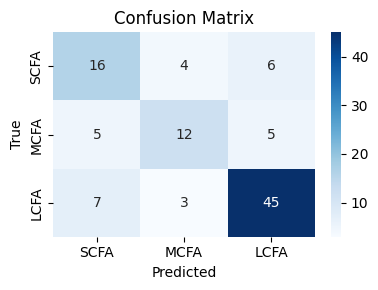


cv training accuracy :  [0.87804878 0.90243902 0.86585366 0.87951807 0.85542169] avg: 0.8762562444901558
cv test accuracy :  [0.76190476 0.76190476 0.57142857 0.65       0.8       ] avg: 0.709047619047619

Misclassified:
                                    id category
0             COND0002697-SCATT_32630     LCFA
8                    COND0002521-psoA     SCFA
12                COND0001363-RSp0641     LCFA
13                   COND0000425-sesA     MCFA
18              COND0000464-XDD1_2281     SCFA
19            COND0002100-DBP21_21655     MCFA
38            COND0001686-BN712_00198     MCFA
48   COND0002660-SAMN04488128_1011792     SCFA
50                   COND0001152-fusA     LCFA
52            COND0002119-J6386_25750     MCFA
55                   COND0001230-sln9     MCFA
59                   COND0000341-endA     LCFA
70         COND0000383-PluTT01m_09655     LCFA
71             COND0001524-Sulba_0748     MCFA
72                  COND0000433-srfAA     LCFA
79                   COND

/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_53927/1469452956.py:49: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle


y = ml_df['category']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)



i=1
X, y = shuffle(X, y, random_state=i)
#X_cv, X_test, y_cv, y_test = train_test_split(X, y, test_size=0.2,stratify=ml_df["category"],shuffle=True, random_state=i)

rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.04,max_depth=5,min_samples_leaf=2,max_leaf_nodes=8, n_estimators=100,min_samples_split=5, max_features="sqrt", random_state=i)
#rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.015,max_depth=5,min_samples_leaf=2, n_estimators=100,min_samples_split=12, max_features="sqrt", random_state=i)
rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.045,max_depth=10,min_samples_leaf=1,max_leaf_nodes=3,n_estimators=100,min_samples_split=15, max_features="log2", random_state=i)
rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.01,max_depth=15,min_samples_leaf=1,max_leaf_nodes=5,n_estimators=100,min_samples_split=10, max_features="sqrt", random_state=i)
#rf_model_cv = RandomForestClassifier(class_weight='balanced',criterion='entropy',ccp_alpha=0.045,max_depth=10,min_samples_leaf=1,max_leaf_nodes=3,n_estimators=100,min_samples_split=10, max_features="log2", random_state=i)
#rf_model_cv = RandomForestClassifier()
#rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.1,max_depth=25,min_samples_leaf=1,max_leaf_nodes=4,n_estimators=100,min_samples_split=4, max_features="sqrt", random_state=i)
#rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.08,max_depth=20,min_samples_leaf=1,max_leaf_nodes=2,n_estimators=100,min_samples_split=3, max_features="sqrt", random_state=i)
#rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.04,max_depth=5,min_samples_leaf=2,max_leaf_nodes=8, n_estimators=100,min_samples_split=5, max_features="sqrt", random_state=i)
rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.075,max_depth=15,min_samples_leaf=1,max_leaf_nodes=4,n_estimators=100,min_samples_split=8, max_features="log2", random_state=i)


cvs = cross_val_score(rf_model_cv, X, y, cv=5)
print(cvs, 'avg:',  avg(cvs))
cvs_pred = cross_val_predict(rf_model_cv, X, y, cv=5)

cvoutput = cross_validate(rf_model_cv, X, y, cv=5, return_train_score=True)


print()
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=['SCFA', 'MCFA',"LCFA" ]), annot=True, fmt='d', cmap='Blues', xticklabels=['SCFA', 'MCFA',"LCFA" ], yticklabels=['SCFA', 'MCFA',"LCFA" ])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
print('\ncv training accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('cv test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
print('\nMisclassified:\n',misclassified.iloc[:,:2])

test set confusion matrix: 


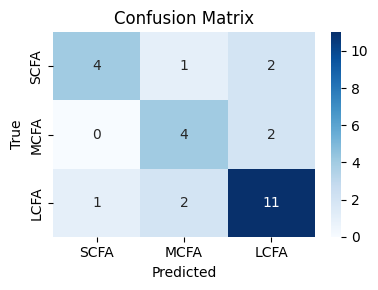

test set :
0.7037037037037037


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix,accuracy_score, balanced_accuracy_score
from sklearn.utils import shuffle


i = 1

y = ml_df['category']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

y_test = ml_df_test['category']
X_test = ml_df_test.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)

rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.075,max_depth=15,min_samples_leaf=1,max_leaf_nodes=4,n_estimators=100,min_samples_split=8, max_features="log2", random_state=i)

# cvs = cross_val_score(rf_model_cv, X, y, cv=5)
# print(cvs, 'avg:',  avg(cvs))
# cvs_pred = cross_val_predict(rf_model_cv, X, y, cv=5)
# cvoutput = cross_validate(rf_model_cv, X, y, cv=5, return_train_score=True)
# print(confusion_matrix(y, cvs_pred, labels=['SCFA', 'MCFA',"LCFA" ]))
# print('\ncv training accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
# print('cv test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

rf_model_cv.fit(X,y)

pred = rf_model_cv.predict(X_test)
print('test set confusion matrix: ')
# print(confusion_matrix(y_test, pred, labels=['SCFA', 'MCFA',"LCFA" ]))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred, labels=['SCFA', 'MCFA',"LCFA" ]), annot=True, fmt='d', cmap='Blues', xticklabels=['SCFA', 'MCFA',"LCFA" ], yticklabels=['SCFA', 'MCFA',"LCFA" ])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
print('test set :')
print(accuracy_score(y_test, pred))

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.metrics import confusion_matrix,accuracy_score, balanced_accuracy_score
from sklearn.utils import shuffle
import pandas as pd


df_tax = pd.read_csv('csv/condensation_starter.csv')


i = 1

# y = ml_df_full['category_simple']
# X = ml_df_full.drop(['id', 'category', 'aligned_seq', 'category_simple', 'size'], axis=1)

with open('test_accuracies_full_size.csv', 'w') as f:
    for i in range(0,200):
        print(i)
        y_test = ml_df_test['category']
        X_test = ml_df_test.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)

        rf_model_cv = RandomForestClassifier(class_weight='balanced',ccp_alpha=0.075,max_depth=15,min_samples_leaf=1,max_leaf_nodes=4,n_estimators=100,min_samples_split=8, max_features="log2", random_state=i)

        
        cvs = cross_val_score(rf_model_cv, X, y, cv=5)
        print(cvs, 'avg:',  avg(cvs))

        #print(y[ml_df_full['tax_cat'] == 'streptomyces'])
        cvs_pred = cross_val_predict(rf_model_cv, X, y, cv=5)
        cvoutput = cross_validate(rf_model_cv, X, y, cv=5, return_train_score=True)
        print(confusion_matrix(y, cvs_pred, labels=['SCFA', 'MCFA',"LCFA" ]))
        # Confusion matrix for 'streptomyces' category
        
        #print(y, cvs_pred)

        trues = []
        preds = []
        c = 0
        # for index, value in y.items():
        #     #print(index,value, cvs_pred[c])
        #     if ml_df_full.at[index, 'tax_cat'] == 'streptomyces':
        #         trues.append(value)
        #         preds.append(cvs_pred[c])
        #     c += 1
        #     #print(y[i], cvs_pred[i])
        # cm = confusion_matrix(trues, preds, labels=['AR', 'FA'])
        # print('filtered_confusion:\n',cm)
        # print('acc', (cm[0][0] + cm[1][1])/(cm[0][0] + cm[1][1] +cm[0][1] + cm[1][0]))

        
        print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))

        print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))
        for testscore in cvoutput['test_score']:
            f.write(str(testscore) + '\n' )


rf_model_cv.fit(X,y)

pred = rf_model_cv.predict(X_test)
print('test set confusion matrix: ')
print(confusion_matrix(y_test, pred, labels=['SCFA', 'MCFA',"LCFA" ]))
print('test set :')
print(accuracy_score(y_test, pred))
print(balanced_accuracy_score(y_test, pred))

0
[0.76190476 0.61904762 0.71428571 0.6        0.8       ] avg: 0.699047619047619
[[15  5  6]
 [ 5 13  4]
 [ 6  5 44]]

training accuracy :  [0.85365854 0.86585366 0.80487805 0.85542169 0.89156627] avg: 0.8542756391419335
test accuracy :  [0.76190476 0.61904762 0.71428571 0.6        0.8       ] avg: 0.699047619047619
1
[0.76190476 0.76190476 0.57142857 0.65       0.8       ] avg: 0.709047619047619
[[16  4  6]
 [ 5 12  5]
 [ 7  3 45]]

training accuracy :  [0.87804878 0.90243902 0.86585366 0.87951807 0.85542169] avg: 0.8762562444901558
test accuracy :  [0.76190476 0.76190476 0.57142857 0.65       0.8       ] avg: 0.709047619047619
2
[0.76190476 0.71428571 0.57142857 0.7        0.85      ] avg: 0.7195238095238096
[[18  2  6]
 [ 6 13  3]
 [ 6  6 43]]

training accuracy :  [0.8902439  0.85365854 0.86585366 0.89156627 0.89156627] avg: 0.8785777255362917
test accuracy :  [0.76190476 0.71428571 0.57142857 0.7        0.85      ] avg: 0.7195238095238096
3
[0.66666667 0.71428571 0.61904762 0.6  

### svm

[0.76190476 0.66666667 0.52380952 0.65       0.75      ] 0.6704761904761904


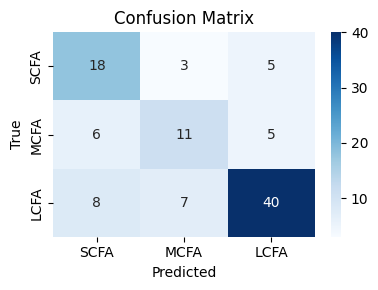


training accuracy :  [0.91463415 0.8902439  0.87804878 0.90361446 0.90361446] avg: 0.8980311489861886
test accuracy :  [0.76190476 0.66666667 0.52380952 0.65       0.75      ] avg: 0.6704761904761904

Misclassified:
                                    id category
0             COND0002697-SCATT_32630     LCFA
7                    COND0000400-pbtA     LCFA
8                    COND0002521-psoA     SCFA
12                COND0001363-RSp0641     LCFA
13                   COND0000425-sesA     MCFA
18              COND0000464-XDD1_2281     SCFA
19            COND0002100-DBP21_21655     MCFA
20           COND0002135-XBJ1_RS10015     LCFA
25             COND0001203-AKA59447.1     MCFA
29                   COND0001715-octA     LCFA
34                   COND0001968-cdeI     LCFA
38            COND0001686-BN712_00198     MCFA
48   COND0002660-SAMN04488128_1011792     SCFA
52            COND0002119-J6386_25750     MCFA
55                   COND0001230-sln9     MCFA
58              COND0002367-SC

/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_53927/2104896083.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [41]:
from sklearn import svm
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

i = 1
y = ml_df['category']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

c = svm.SVC(probability=True,degree = 4, C = 0.65,class_weight='balanced',gamma='auto', kernel='rbf')
cvs = cross_val_score(c, X, y, cv=5)
cvs_pred = cross_val_predict(c, X, y, cv=5)
print(cvs, avg(cvs))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=['SCFA', 'MCFA',"LCFA" ]), annot=True, fmt='d', cmap='Blues', xticklabels=['SCFA', 'MCFA',"LCFA" ], yticklabels=['SCFA', 'MCFA',"LCFA" ])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cvoutput = cross_validate(c, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
print('\nMisclassified:\n',misclassified.iloc[:,:2])

test set confusion matrix: 


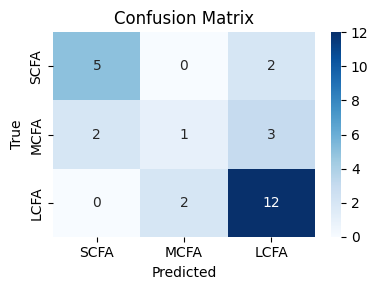

test set :
0.6666666666666666


In [49]:
from sklearn import svm
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

i = 1

y = ml_df['category']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

y_test = ml_df_test['category']
X_test = ml_df_test.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)

c = svm.SVC(probability=True,degree=5,C = 1.2, break_ties=True,class_weight='balanced', kernel='poly')


c.fit(X,y)

pred = c.predict(X_test)
print('test set confusion matrix: ')
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred, labels=['SCFA', 'MCFA',"LCFA" ]), annot=True, fmt='d', cmap='Blues', xticklabels=['SCFA', 'MCFA',"LCFA" ], yticklabels=['SCFA', 'MCFA',"LCFA" ])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
print('test set :')
print(accuracy_score(y_test, pred))



### logistic regression

[0.76190476 0.66666667 0.52380952 0.6        0.85      ] 0.6804761904761905


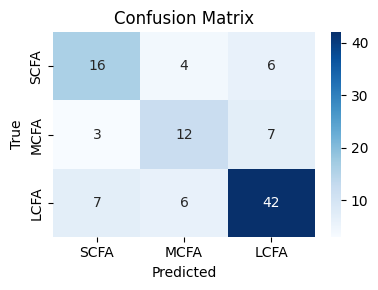


training accuracy :  [0.92682927 0.91463415 0.86585366 0.92771084 0.87951807] avg: 0.9029091977666764
test accuracy :  [0.76190476 0.66666667 0.52380952 0.6        0.85      ] avg: 0.6804761904761905
                           id category
0     COND0002697-SCATT_32630     LCFA
8            COND0002521-psoA     SCFA
10     COND0001608-AAW51_2719     LCFA
12        COND0001363-RSp0641     LCFA
13           COND0000425-sesA     MCFA
18      COND0000464-XDD1_2281     SCFA
19    COND0002100-DBP21_21655     MCFA
20   COND0002135-XBJ1_RS10015     LCFA
25     COND0001203-AKA59447.1     MCFA
29           COND0001715-octA     LCFA
38    COND0001686-BN712_00198     MCFA
51     COND0002581-QKF54435.2     SCFA
52    COND0002119-J6386_25750     MCFA
55           COND0001230-sln9     MCFA
58      COND0002367-SCAB_3321     LCFA
59           COND0000341-endA     LCFA
79           COND0001050-ttbA     LCFA
84           COND0002424-sacE     LCFA
90           COND0001876-ttcA     LCFA
97        COND00013

/var/folders/rt/kl_lws993wvbgr3lkh7w2g8r0000gn/T/ipykernel_53927/1786514655.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  misclassified = ml_df[y != cvs_pred]


In [50]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, ARDRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
import pandas as pd
from sklearn.metrics import confusion_matrix

i = 1
y = ml_df['category']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)
X, y = shuffle(X, y, random_state=i)

lreg = LogisticRegression(solver='newton-cg', class_weight='balanced', penalty='l2', C=0.01)

cvs = cross_val_score(lreg, X, y, cv=5)
cvs_pred = cross_val_predict(lreg, X, y, cv=5)
print(cvs, avg(cvs))
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y, cvs_pred, labels=['SCFA', 'MCFA',"LCFA" ]), annot=True, fmt='d', cmap='Blues', xticklabels=['SCFA', 'MCFA',"LCFA" ], yticklabels=['SCFA', 'MCFA',"LCFA" ])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
cvoutput = cross_validate(lreg, X, y, cv=5, return_train_score=True)
print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

misclassified = ml_df[y != cvs_pred]
print(misclassified.iloc[:,:2])

test set confusion matrix: 


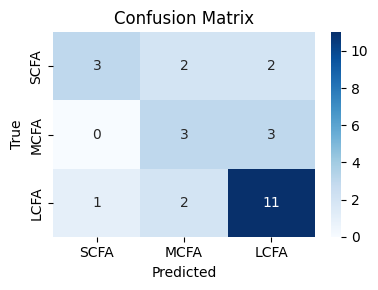

test set :
0.6296296296296297


In [51]:
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

i = 1
y = ml_df['category']
X = ml_df.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)
X, y = shuffle(X, y,random_state=i)

y_test = ml_df_test['category']
X_test = ml_df_test.drop(['id', 'category', 'aligned_seq', 'size'], axis=1)

lreg = LogisticRegression(solver='liblinear', class_weight='balanced', penalty='l2', C=0.04)
lreg = LogisticRegression(solver='newton-cg', class_weight='balanced', penalty='l2', C=0.01)
cvs = cross_val_score(lreg, X, y, cv=5)
# print(cvs, 'avg:',  avg(cvs))
# cvs_pred = cross_val_predict(lreg, X, y, cv=5)
# cvoutput = cross_validate(lreg, X, y, cv=5, return_train_score=True)
# print(confusion_matrix(y, cvs_pred, labels=["SCFA", "MCFA", "LCFA"]))
# print('\ntraining accuracy : ',cvoutput['train_score'], 'avg:',  avg(cvoutput['train_score']))
# print('test accuracy : ',cvoutput['test_score'], 'avg:',  avg(cvoutput['test_score']))

#misclassified = ml_df[y != cvs_pred]
#print(misclassified.iloc[:,:2])

lreg.fit(X,y)

pred = lreg.predict(X_test)
print('test set confusion matrix: ')
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred, labels=['SCFA', 'MCFA',"LCFA" ]), annot=True, fmt='d', cmap='Blues', xticklabels=['SCFA', 'MCFA',"LCFA" ], yticklabels=['SCFA', 'MCFA',"LCFA" ])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
print('test set :')
print(accuracy_score(y_test, pred))